# Algorithme de Grover sur bases de données pondérées

Article **“Quantum search algorithm on weighted databases”** de Yifan Sun et Lian-Ao Wu.

L'objectif est de reproduire et d'explorer numériquement les résultats principaux de l'article :

1. la formulation de la recherche de Grover sur une base de données pondérée ;
2. la dynamique discrète donnée par les relations de récurrence ;
3. l'approximation continue par équation différentielle ;
4. le cas uniforme, qui redonne le comportement standard en $O(\sqrt{N})$ ;
5. le cas d'une distribution issue d'un état cohérent tronqué ;
6. la comparaison entre le nombre d'étapes classique et celui estimé pour l'évolution de Grover.

## 1. Modèle : base de données pondérée

L'article considère une base de données formée de $N$ types distincts :

$$
\{(y_1,p_1),\dots,(y_N,p_N)\},
$$

où $p_k$ est la proportion, ou probabilité, associée au type $y_k$.

Le codage quantique considéré est un état

$$
|D\rangle = \sum_{n=1}^N P(n)|n\rangle,
\qquad |P(n)|^2 = p_n,
\qquad \sum_{n=1}^N |P(n)|^2 = 1.
$$

Pour chercher l'état cible $|k\rangle$, l'article définit les deux réflexions

$$
U_D = 2|D\rangle\langle D|-I,
\qquad
U_k = I - 2|k\rangle\langle k|,
$$

puis l'opérateur d'amplification

$$
G = U_D U_k.
$$

## 2. Dynamique discrète dans le sous-espace engendré par $|D\rangle$ et $|k\rangle$

L'article écrit, après $r$ applications de $G$ :

$$
G^r |D\rangle = a_r |D\rangle + b_r |k\rangle.
$$

Les coefficients suivent la récurrence

$$
\begin{aligned}
a_r &= \left(1-4|P(k)|^2\right)a_{r-1} - 2P^*(k)b_{r-1},\\
b_r &= b_{r-1} + 2P(k)a_{r-1}.
\end{aligned}
$$

Ici on prend $P(k)$ réel et positif, comme dans les exemples numériques de l'article où seules les amplitudes sont comparées.

In [3]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

def recurrence_coefficients(Pk, r_max=80):
    """
    Calcule les coefficients a_r et b_r de l'article.

    Convention utilisée dans l'article pour les figures :
    a_1 = 1 - 4|P(k)|^2, b_1 = 2P(k).
    """
    Pk = float(Pk)
    a = np.zeros(r_max + 1, dtype=float)
    b = np.zeros(r_max + 1, dtype=float)

    a[1] = 1 - 4 * Pk**2
    b[1] = 2 * Pk

    for r in range(2, r_max + 1):
        a[r] = (1 - 4 * Pk**2) * a[r-1] - 2 * Pk * b[r-1]
        b[r] = b[r-1] + 2 * Pk * a[r-1]

    return a, b


def continuous_approximation(Pk, x):
    """
    Approximation continue issue de l'équation différentielle de l'article.

    f_a'' + 4|P(k)|^2 f_a' + 4|P(k)|^2 f_a = 0.

    On impose les mêmes conditions initiales que dans les figures :
    f_a(0) = 1 - 4 Pk^2, f_b(0) = 2 Pk,
    avec f_b = f_a' / (2Pk) d'après f_b' = 2Pk f_a.

    Pour f_a, la solution utilisée est :
    f_a(x) = exp(-2p^2 x) [C1 cos(beta x) + C2 sin(beta x)],
    beta = 2 sqrt(p^2 - p^4).
    """
    Pk = float(Pk)
    x = np.asarray(x, dtype=float)

    if Pk == 0:
        raise ValueError("Pk doit être non nul.")
    if Pk >= 1:
        raise ValueError("Le cas Pk=1 est trivial et n'est pas traité ici.")

    gamma = -2 * Pk**2
    beta = 2 * math.sqrt(Pk**2 - Pk**4)

    C1 = 1 - 4 * Pk**2
    # Relation à x=0 : f_a'(0) = -4 f_a(0) Pk^2 - 2 f_b(0) Pk
    fa_prime_0 = -4 * C1 * Pk**2 - 2 * (2 * Pk) * Pk
    C2 = (fa_prime_0 - gamma * C1) / beta

    fa = np.exp(gamma * x) * (C1 * np.cos(beta * x) + C2 * np.sin(beta * x))

    # Pour rester fidèle à la relation différentielle : f_b' = 2Pk f_a.
    # On reconstruit f_b numériquement avec f_b(0)=2Pk.
    fb = np.empty_like(x, dtype=float)
    fb[0] = 2 * Pk
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        fb[i] = fb[i-1] + 2 * Pk * 0.5 * (fa[i] + fa[i-1]) * dx

    return fa, fb


def grover_step_estimate(Pk):
    """
    Estimateur de l'article : ordre du nombre d'étapes ~ 1 / \tilde{Delta},
    avec \tilde{Delta} = sqrt(|P(k)|^2 - |P(k)|^4).
    """
    Pk = np.asarray(Pk, dtype=float)
    delta_tilde = np.sqrt(Pk**2 - Pk**4)
    return 1 / delta_tilde

print("Cellule 3 terminée : fonctions chargées.")


Cellule 3 terminée : fonctions chargées.


## 3. Cas uniforme : retour à la recherche non structurée

Dans le cas uniforme,

$$
P(k) = \frac{1}{\sqrt{N}}.
$$

Alors

$$
\tilde{\Delta}
= \sqrt{\frac{1}{N}-\frac{1}{N^2}}
= \frac{\sqrt{N-1}}{N}
\approx \frac{1}{\sqrt{N}}
$$

pour $N$ grand. L'article retrouve ainsi un nombre d'étapes d'ordre $\sqrt{N}$, à comparer à l'ordre $N$ pour la recherche classique.

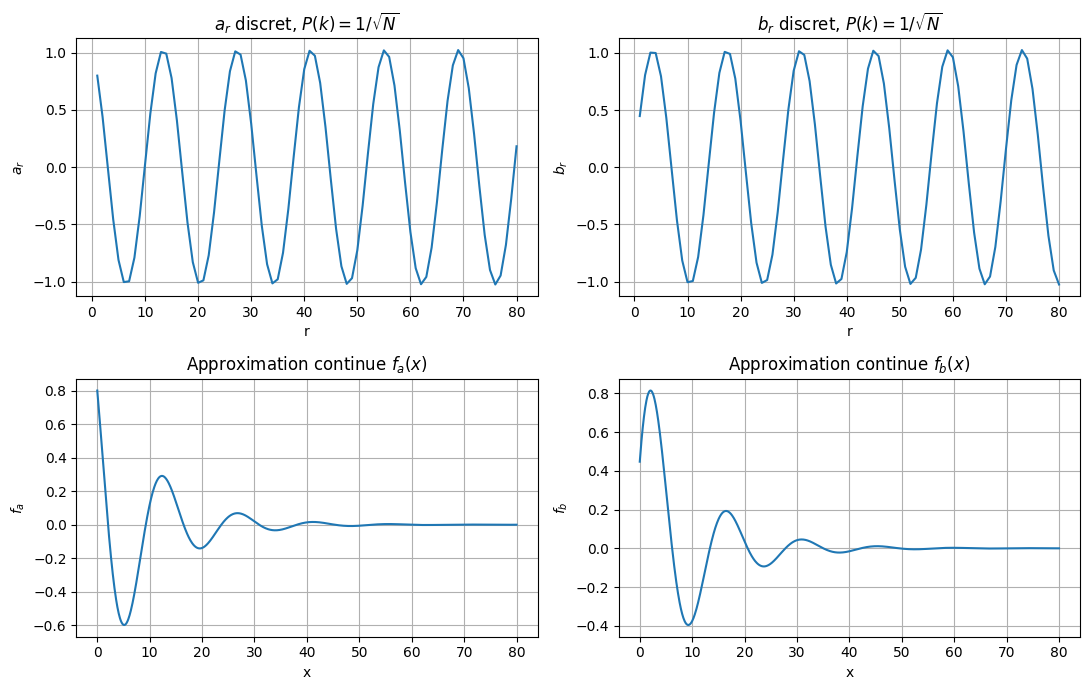

N = 20
P(k) = 0.223607
Étapes Grover estimées ~ 4.588
Étapes classiques ~ N = 20
Cellule 5 terminée.


In [4]:
N = 20
Pk_uniform = 1 / math.sqrt(N)
r_max = 80

r = np.arange(r_max + 1)
a, b = recurrence_coefficients(Pk_uniform, r_max=r_max)

x = np.linspace(0, r_max, 1000)
fa, fb = continuous_approximation(Pk_uniform, x)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(r[1:], a[1:])
axes[0, 0].set_title(r"$a_r$ discret, $P(k)=1/\sqrt{N}$")
axes[0, 0].set_xlabel("r")
axes[0, 0].set_ylabel(r"$a_r$")

axes[0, 1].plot(r[1:], b[1:])
axes[0, 1].set_title(r"$b_r$ discret, $P(k)=1/\sqrt{N}$")
axes[0, 1].set_xlabel("r")
axes[0, 1].set_ylabel(r"$b_r$")

axes[1, 0].plot(x, fa)
axes[1, 0].set_title(r"Approximation continue $f_a(x)$")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel(r"$f_a$")

axes[1, 1].plot(x, fb)
axes[1, 1].set_title(r"Approximation continue $f_b(x)$")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel(r"$f_b$")

plt.tight_layout()
plt.show()
plt.close("all")

print(f"N = {N}")
print(f"P(k) = {Pk_uniform:.6f}")
print(f"Étapes Grover estimées ~ {grover_step_estimate(Pk_uniform):.3f}")
print(f"Étapes classiques ~ N = {N}")
print("Cellule 5 terminée.")


## 4. Distribution issue d'un état cohérent tronqué

L'article considère ensuite l'état cohérent

$$
|\alpha\rangle
= e^{-\frac{1}{2}|\alpha|^2}\sum_{q=0}^{\infty}\frac{\alpha^q}{\sqrt{q!}}|q\rangle.
$$

Pour une base de données finie, il tronque cet état sur une fenêtre de taille $N$ :

$$
|\alpha'\rangle
= \mathcal{N}_q\sum_{q=q_1}^{q_1+N}
e^{-\frac{1}{2}|\alpha|^2}\frac{\alpha^q}{\sqrt{q!}}|q\rangle.
$$

Le facteur de normalisation est

$$
\mathcal{N}_q
= \left[\sum_{q=q_1}^{q_1+N}
e^{-|\alpha|^2}\frac{|\alpha|^{2q}}{q!}\right]^{-1/2}.
$$

L'amplitude du niveau cible $|k\rangle$ est alors

$$
|P(k)|
= \frac{|\alpha|^k}{\sqrt{k!}}
\left[\sum_{q=q_1}^{q_1+N}\frac{|\alpha|^{2q}}{q!}\right]^{-1/2}.
$$

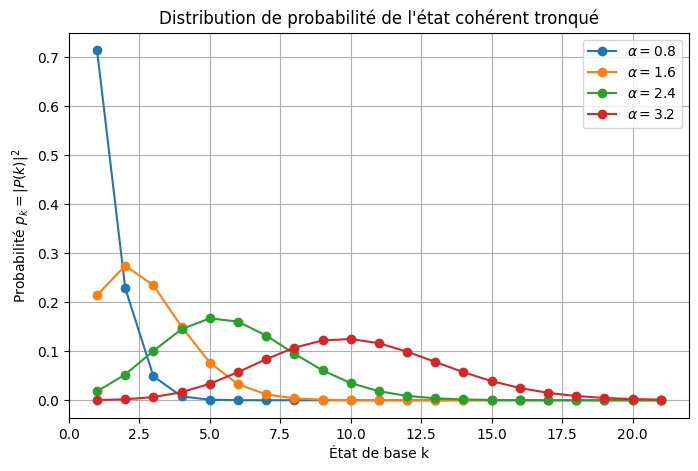

Cellule 7 terminée.


In [5]:
def coherent_truncated_amplitudes(alpha, q1=1, N=20):
    """
    Amplitudes |P(k)| pour l'état cohérent tronqué de l'article.

    On utilise les indices k = q1, ..., q1+N.
    Pour éviter les dépassements numériques, on calcule via log-factorielle.
    """
    ks = np.arange(q1, q1 + N + 1)
    log_weights = 2 * ks * np.log(abs(alpha)) - np.array([math.lgamma(k + 1) for k in ks])
    # Normalisation stable
    m = np.max(log_weights)
    weights = np.exp(log_weights - m)
    probabilities = weights / weights.sum()
    amplitudes = np.sqrt(probabilities)
    return ks, amplitudes, probabilities

alphas = [0.8, 1.6, 2.4, 3.2]
q1 = 1
N_coh = 20

plt.figure(figsize=(8, 5))
for alpha in alphas:
    ks, amps, probs = coherent_truncated_amplitudes(alpha, q1=q1, N=N_coh)
    plt.plot(ks, probs, marker="o", label=fr"$\alpha={alpha}$")
plt.xlabel("État de base k")
plt.ylabel(r"Probabilité $p_k = |P(k)|^2$")
plt.title("Distribution de probabilité de l'état cohérent tronqué")
plt.legend()
plt.show()
plt.close("all")
print("Cellule 7 terminée.")


## 5. Dynamique discrète et approximation continue pour la distribution cohérente

L'article compare ensuite la récurrence discrète avec l'approximation continue pour une cible fixée, par exemple $k=3$, et pour plusieurs valeurs de $\alpha$.

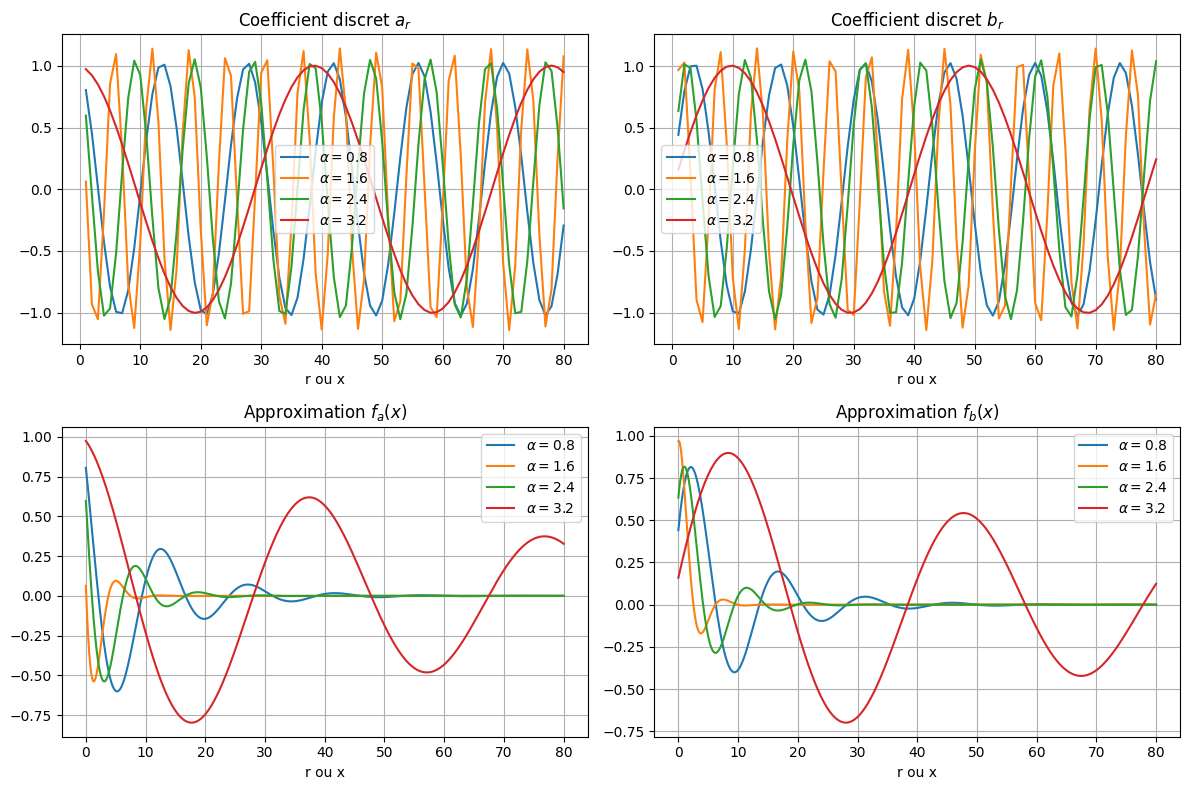

Cellule 9 terminée.


In [6]:
target_k = 3
r_max = 80
r = np.arange(r_max + 1)
x = np.linspace(0, r_max, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for alpha in alphas:
    ks, amps, probs = coherent_truncated_amplitudes(alpha, q1=q1, N=N_coh)
    idx = np.where(ks == target_k)[0][0]
    Pk = amps[idx]

    a, b = recurrence_coefficients(Pk, r_max=r_max)
    fa, fb = continuous_approximation(Pk, x)

    axes[0, 0].plot(r[1:], a[1:], label=fr"$\alpha={alpha}$")
    axes[0, 1].plot(r[1:], b[1:], label=fr"$\alpha={alpha}$")
    axes[1, 0].plot(x, fa, label=fr"$\alpha={alpha}$")
    axes[1, 1].plot(x, fb, label=fr"$\alpha={alpha}$")

axes[0, 0].set_title(r"Coefficient discret $a_r$")
axes[0, 1].set_title(r"Coefficient discret $b_r$")
axes[1, 0].set_title(r"Approximation $f_a(x)$")
axes[1, 1].set_title(r"Approximation $f_b(x)$")

for ax in axes.flat:
    ax.set_xlabel("r ou x")
    ax.legend()

plt.tight_layout()
plt.show()
plt.close("all")
print("Cellule 9 terminée.")


## 6. Comparaison entre recherche classique et évolution de Grover

Pour une cible $|k\rangle$ :

- le nombre d'étapes classique est d'ordre

$$
s_{\mathrm{classique}}(k) \sim \frac{1}{p_k}
= \frac{1}{|P(k)|^2} ;
$$

- le nombre d'étapes estimé pour Grover est d'ordre

$$
s_{\mathrm{Grover}}(k) \sim \frac{1}{\tilde{\Delta}(k)},
\qquad
\tilde{\Delta}(k)=\sqrt{|P(k)|^2-|P(k)|^4}.
$$

L'article compare aussi les inverses des nombres d'étapes. On a alors :

$$
\frac{1}{s_{\mathrm{classique}}} \sim p_k,
\qquad
\frac{1}{s_{\mathrm{Grover}}} \sim \tilde{\Delta}(k).
$$

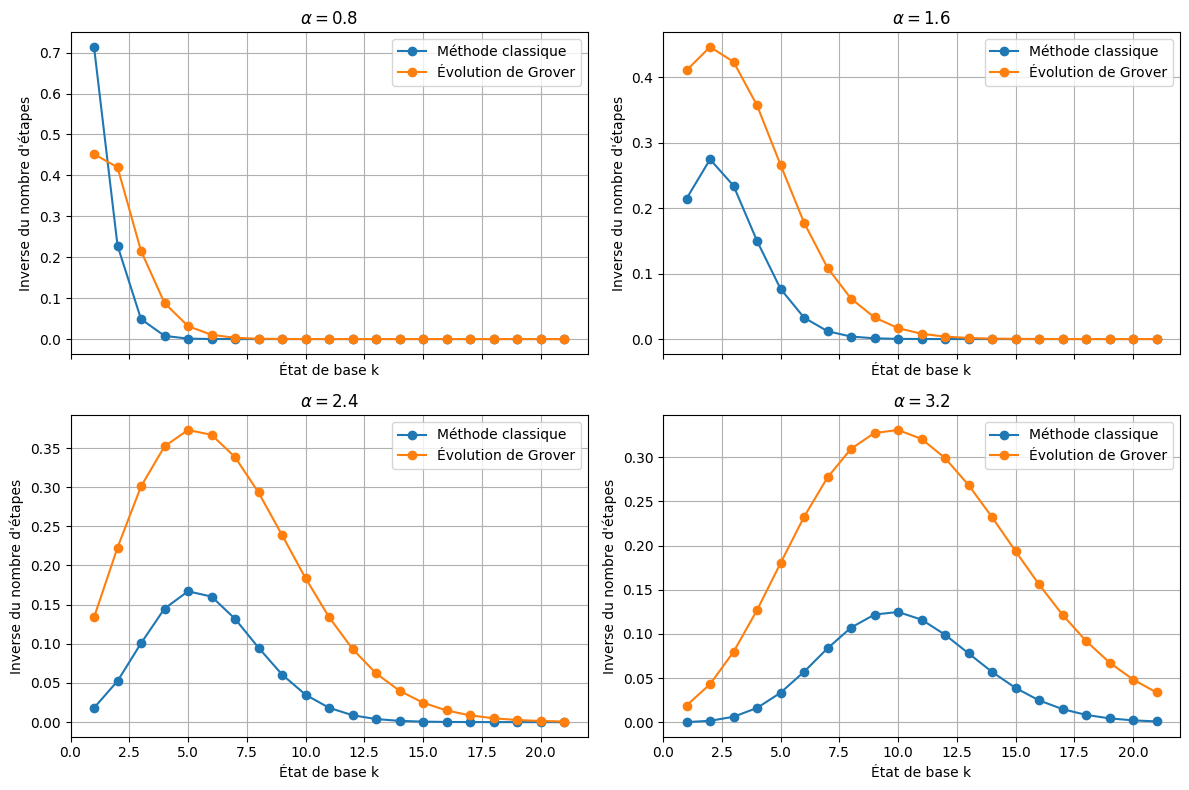

Cellule 11 terminée.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, alpha in zip(axes, alphas):
    ks, amps, probs = coherent_truncated_amplitudes(alpha, q1=q1, N=N_coh)
    delta_tilde = np.sqrt(amps**2 - amps**4)

    ax.plot(ks, probs, marker="o", label="Méthode classique")
    ax.plot(ks, delta_tilde, marker="o", label="Évolution de Grover")
    ax.set_title(fr"$\alpha={alpha}$")
    ax.set_xlabel("État de base k")
    ax.set_ylabel("Inverse du nombre d'étapes")
    ax.legend()

plt.tight_layout()
plt.show()
plt.close("all")
print("Cellule 11 terminée.")


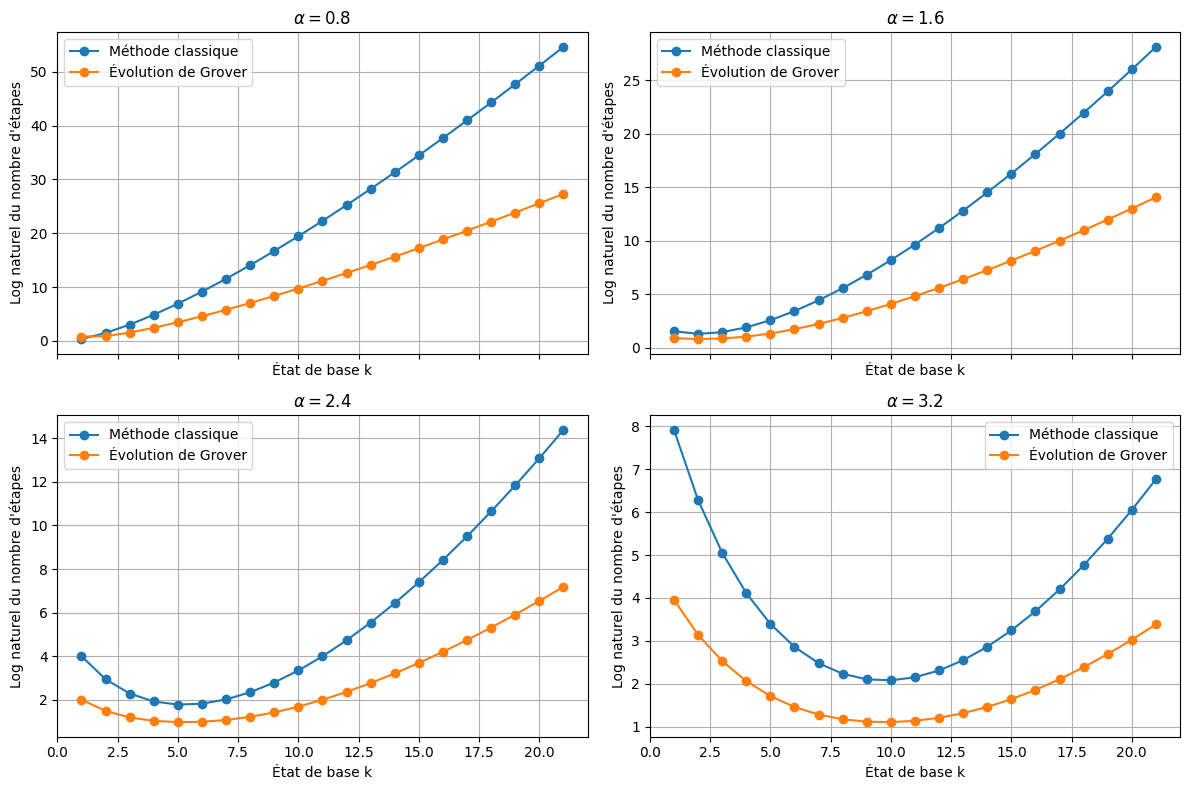

Cellule 12 terminée.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, alpha in zip(axes, alphas):
    ks, amps, probs = coherent_truncated_amplitudes(alpha, q1=q1, N=N_coh)
    classical_steps = 1 / probs
    grover_steps = grover_step_estimate(amps)

    ax.plot(ks, np.log(classical_steps), marker="o", label="Méthode classique")
    ax.plot(ks, np.log(grover_steps), marker="o", label="Évolution de Grover")
    ax.set_title(fr"$\alpha={alpha}$")
    ax.set_xlabel("État de base k")
    ax.set_ylabel("Log naturel du nombre d'étapes")
    ax.legend()

plt.tight_layout()
plt.show()
plt.close("all")
print("Cellule 12 terminée.")


## 7. Condition locale de speed-up

L'article donne une condition locale de speed-up pour la recherche d'un élément $k$ :

$$
\tilde{\Delta}^{-1}(k) < \frac{1}{p_k}.
$$

Comme $p_k=|P(k)|^2$, cela revient à comparer l'estimation d'étapes Grover avec l'estimation classique.

Le code ci-dessous affiche, pour chaque $\alpha$, les états pour lesquels l'estimation de Grover est meilleure.

In [9]:
for alpha in alphas:
    ks, amps, probs = coherent_truncated_amplitudes(alpha, q1=q1, N=N_coh)
    classical_steps = 1 / probs
    grover_steps = grover_step_estimate(amps)
    speedup = grover_steps < classical_steps

    print(f"alpha = {alpha}")
    print("États avec speed-up local estimé :", ks[speedup].tolist())
    print("États sans speed-up local estimé :", ks[~speedup].tolist())
    print()
print("Cellule 14 terminée.")


alpha = 0.8
États avec speed-up local estimé : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
États sans speed-up local estimé : [1]

alpha = 1.6
États avec speed-up local estimé : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
États sans speed-up local estimé : []

alpha = 2.4
États avec speed-up local estimé : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
États sans speed-up local estimé : []

alpha = 3.2
États avec speed-up local estimé : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
États sans speed-up local estimé : []

Cellule 14 terminée.


## 8. Conclusion

- la recherche se fait sur une base pondérée encodée dans les amplitudes $P(k)$ ;
- l'évolution de Grover est étudiée par les coefficients $a_r$ et $b_r$ ;
- l'approximation continue donne une estimation du nombre d'étapes via $\tilde{\Delta}^{-1}$ ;
- le cas uniforme retrouve l'ordre $\sqrt{N}$ ;
- le cas cohérent tronqué montre un avantage local de Grover sur une large partie des états, avec une exception possible lorsque la probabilité de la cible est déjà trop grande.